# — Analyse des Avis App Store Tahoma by Somfy

1. Chargement des données & EDA
2. NLP


## 0. Imports

In [1]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.0 MB/s eta 0:00:00


In [2]:
!pip install Unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.2 MB/s eta 0:00:00


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings, spacy, emoji
from unidecode import unidecode
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_palette('husl')
%matplotlib inline

## 1. Chargement des données

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Tous_les_Avis_AppStore.json to Tous_les_Avis_AppStore.json


In [5]:
import json
import pandas as pd

# Lire le fichier brut
with open('Tous_les_Avis_AppStore.json', 'r', encoding='utf-8') as f:
    content = f.read()

# Corriger le format JSON
content_fixed = '[' + content.strip().rstrip(',') + ']'

# Charger les données
data = json.loads(content_fixed)

# Convertir en DataFrame
df = pd.DataFrame(data)

# Vérification
print(df.shape)
print(df.columns)

df.head()

(500, 7)
Index(['Date', 'Auteur', 'Note', 'Version', 'Titre', 'Commentaire', 'Votes'], dtype='object')


,Date,Auteur,Note,Version,Titre,Commentaire,Votes
0,20/04/2026 12:03,Bientôt Cinquantenaire....,1,2.4.1,Complément nulle !,Rendez nous la version précédente … la program...,0
1,15/04/2026 22:20,guillzule21250,4,2.4.1,Bien mais perfectible,Application claire et simple.\nManque encore l...,0
2,12/04/2026 23:48,Bliblablouble,5,2.4.1,Top,"Merci au support pour la réponse, ras dorenava...",0
3,11/04/2026 13:40,末っ子パスカル,1,2.4.1,Fastidieux,Application qui fonctionne quand elle a le tem...,0
4,10/04/2026 12:58,Mobi75,1,2.4.1,Fermeture automatique crépuscule,"Depuis deux semaines, à la fermeture automatiq...",0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         500 non-null    object
 1   Auteur       500 non-null    object
 2   Note         500 non-null    int64 
 3   Version      500 non-null    object
 4   Titre        500 non-null    object
 5   Commentaire  500 non-null    object
 6   Votes        500 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 27.5+ KB


In [9]:
df.isnull().sum()

,0
Date,0
Auteur,0
Note,0
Version,0
Titre,0
Commentaire,0
Votes,0


## 2. EDA — Analyse Exploratoire
# **Distribution des Notes**

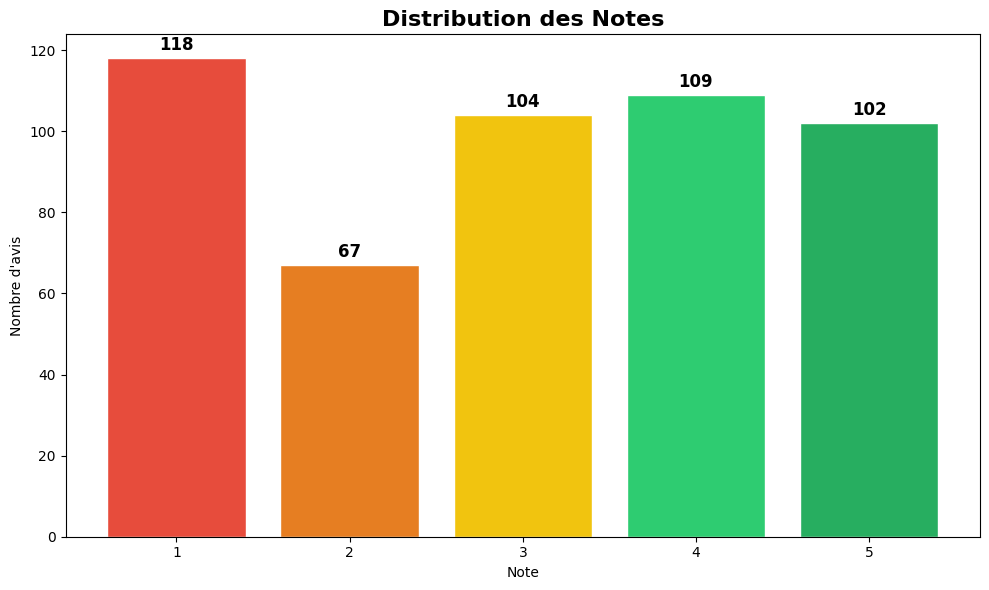

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
note_counts = df['Note'].value_counts().sort_index()
colors_notes = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = ax.bar(note_counts.index, note_counts.values, color=colors_notes, edgecolor='white')
for b, c in zip(bars, note_counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(c), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Distribution des Notes', fontsize=16, fontweight='bold')
ax.set_xlabel('Note'); ax.set_ylabel("Nombre d'avis"); ax.set_xticks([1,2,3,4,5])
plt.tight_layout(); plt.show()

# **Distribution des Votes**

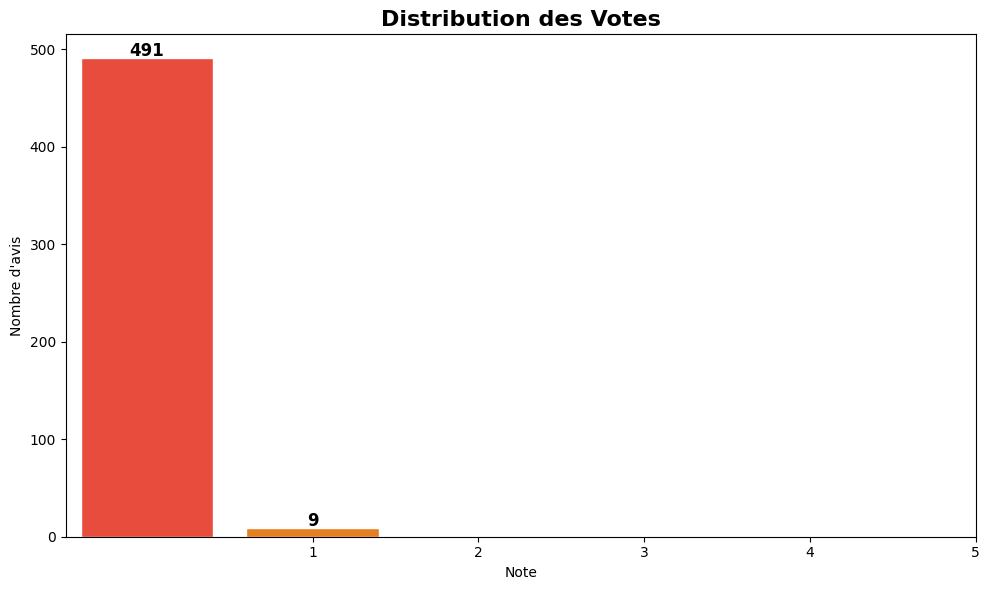

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
note_counts = df['Votes'].value_counts().sort_index()
colors_notes = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = ax.bar(note_counts.index, note_counts.values, color=colors_notes, edgecolor='white')
for b, c in zip(bars, note_counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(c), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Distribution des Votes', fontsize=16, fontweight='bold')
ax.set_xlabel('Note'); ax.set_ylabel("Nombre d'avis"); ax.set_xticks([1,2,3,4,5])
plt.tight_layout(); plt.show()

# **Ajout une classe satisfaction (positive , negative , neutre)**

In [12]:

def get_sentiment(note):
    if note <= 2:
        return 'negative'
    elif note == 3:
        return 'neutral'
    else:
        return 'positive'

# Création de la colonne satisfaction
df['satisfaction'] = df['Note'].apply(get_sentiment)


df[['Note', 'satisfaction']].head()

,Note,satisfaction
0,1,negative
1,4,positive
2,5,positive
3,1,negative
4,1,negative


# **Distribution de la Satisfaction**

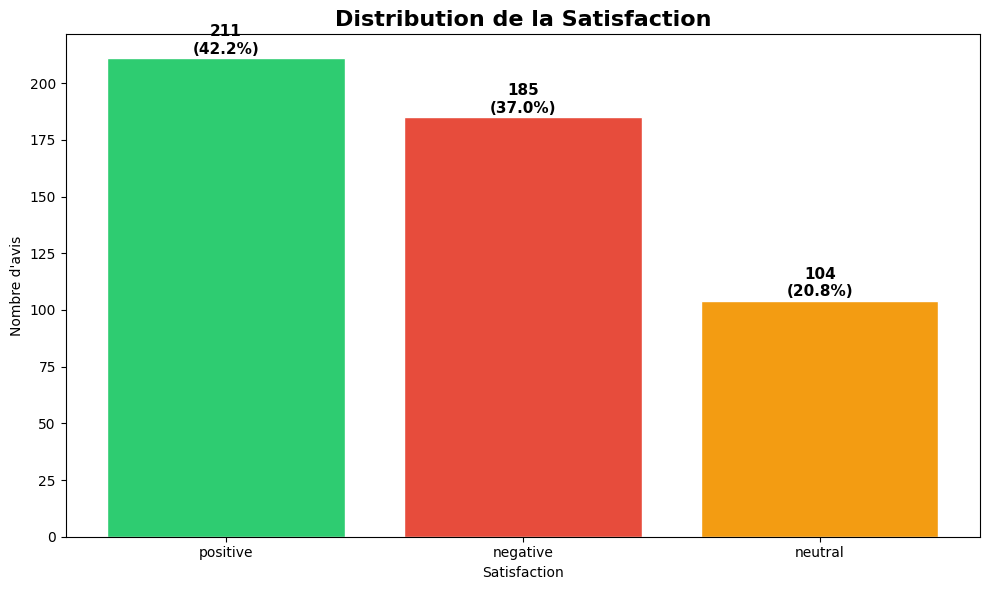

In [13]:
colors_sat = {'positive':'#2ecc71','negative':'#e74c3c','neutral':'#f39c12'}
fig, ax = plt.subplots(figsize=(10, 6))
sat_counts = df['satisfaction'].value_counts()
bars = ax.bar(sat_counts.index, sat_counts.values,
              color=[colors_sat.get(x,'#3498db') for x in sat_counts.index], edgecolor='white')
for b, c in zip(bars, sat_counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2, f'{c}\n({c/len(df)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Distribution de la Satisfaction', fontsize=16, fontweight='bold')
ax.set_xlabel('Satisfaction'); ax.set_ylabel("Nombre d'avis")
plt.tight_layout(); plt.show()

# **Versions & Évolution temporelle**

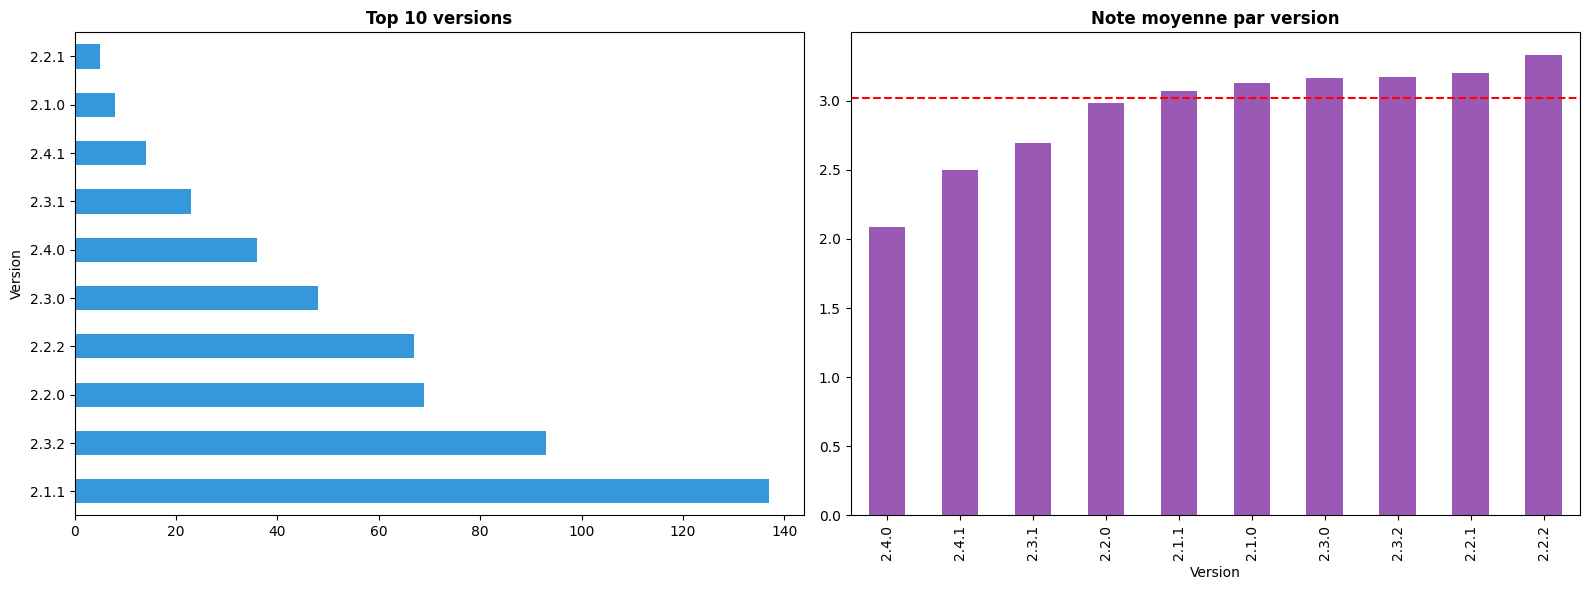

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['Version'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Top 10 versions', fontweight='bold')
df.groupby('Version')['Note'].mean().sort_values().plot(kind='bar', ax=axes[1], color='#9b59b6')
axes[1].set_title('Note moyenne par version', fontweight='bold')
axes[1].axhline(y=df['Note'].mean(), color='red', linestyle='--')
plt.tight_layout(); plt.show()

# **Note par mois**

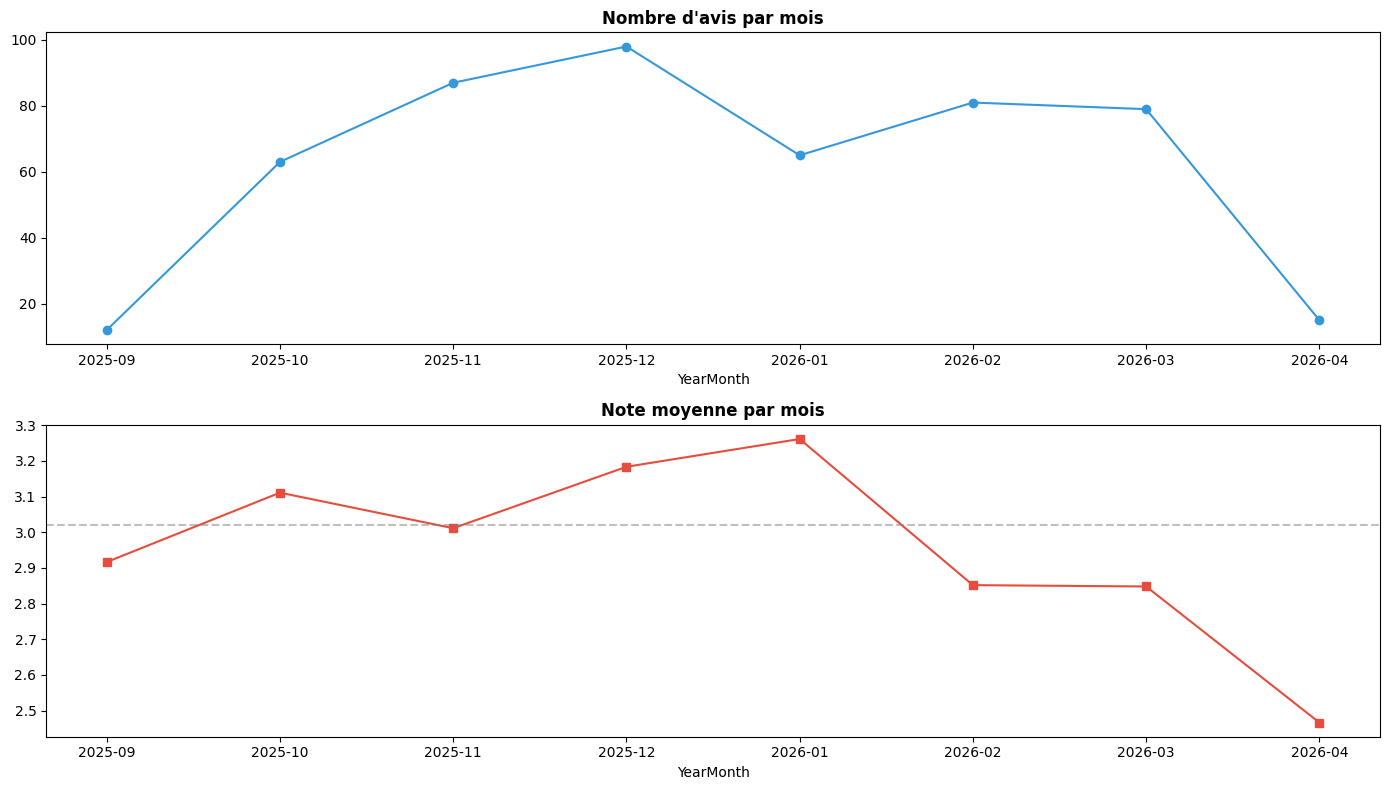

In [18]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y %H:%M')

df = df.sort_values('Date').reset_index(drop=True)


df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)


fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df.groupby('YearMonth').size().plot(
    ax=axes[0],
    marker='o',
    color='#3498db'
)

axes[0].set_title("Nombre d'avis par mois", fontweight='bold')


df.groupby('YearMonth')['Note'].mean().plot(
    ax=axes[1],
    marker='s',
    color='#e74c3c'
)

axes[1].set_title('Note moyenne par mois', fontweight='bold')

axes[1].axhline(
    y=df['Note'].mean(),
    color='gray',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [20]:
print(df.columns)

Index(['Date', 'Auteur', 'Note', 'Version', 'Titre', 'Commentaire', 'Votes',
       'satisfaction', 'YearMonth'],
      dtype='object')


# **Longueur des commentaires**

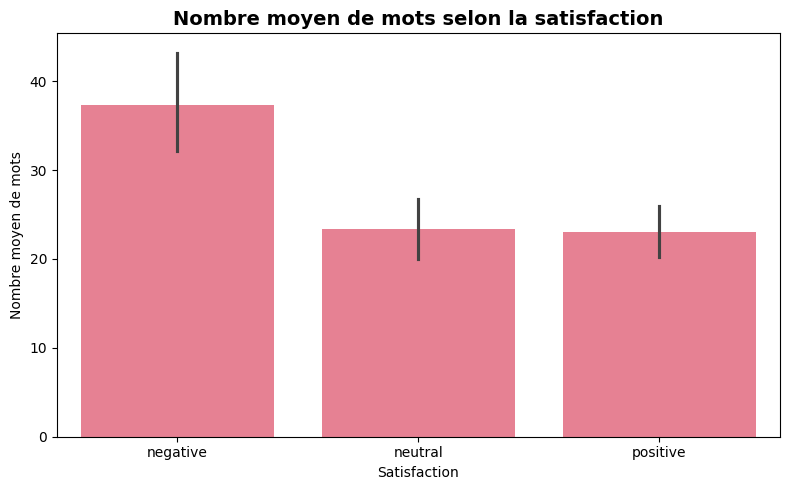

In [21]:
df['word_count'] = df['Commentaire'].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='satisfaction',
    y='word_count',
    order=['negative', 'neutral', 'positive']
)

plt.title('Nombre moyen de mots selon la satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction')
plt.ylabel('Nombre moyen de mots')

plt.tight_layout()
plt.show()

## NLP — Prétraitement

In [22]:
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 105.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [23]:
import spacy

nlp = spacy.load("fr_core_news_sm")

In [24]:
import re
import spacy
import emoji

from unidecode import unidecode

nlp = spacy.load("fr_core_news_sm")

def clean_text(text):

    # sécurité
    text = str(text)

    # minuscules
    text = text.lower()

    # supprimer emojis
    text = emoji.replace_emoji(
        text,
        replace=''
    )

    # supprimer urls
    text = re.sub(
        r'http\S+',
        '',
        text
    )

    # supprimer caractères spéciaux
    text = re.sub(
        r'[^a-zA-ZÀ-ÿ\s]',
        ' ',
        text
    )

    # supprimer accents
    text = unidecode(text)

    # NLP
    doc = nlp(text)

    tokens = []

    for token in doc:

        # ignorer espaces et ponctuation
        if token.is_punct or token.is_space:
            continue

        word = token.text.strip()

        # garder les mots > 2 lettres
        if len(word) > 2:

            tokens.append(word)

    return ' '.join(tokens)

In [25]:
df['clean_commentaire'] = df['Commentaire'].apply(clean_text)

In [30]:
df['clean_Titre'] = df['Titre'].apply(clean_text)

In [26]:
df[['Commentaire', 'clean_commentaire', 'satisfaction']].head(10)

,Commentaire,clean_commentaire,satisfaction
0,"Belle interface sur iPhone, il manque juste la...",belle interface sur iphone manque juste foncti...,neutral
1,Je trouve que la nouvelle appli n’est vraiment...,trouve que nouvelle appli est vraiment pas int...,negative
2,Instantanément. Intelligent. Connecté.,instantanement intelligent connecte,positive
3,"Très utile, plus besoin de penser à ce qu’il f...",tres utile plus besoin penser faut faire surto...,positive
4,L’app est simple et pratique mais il y a une s...,app est simple pratique mais une sorte big qui...,neutral
5,Malheureusement c’est un produit qui n’est abs...,malheureusement est produit qui est absolument...,negative
6,Je trouve ça dommage qu’on peut pas utiliser l...,trouve dommage peut pas utiliser application s...,positive
7,C’est pas possible de pondre de la domotique s...,est pas possible pondre domotique complique ja...,negative
8,Après une nouvelle mise à jour. Toujours pas d...,apres une nouvelle mise jour toujours pas comp...,negative
9,Impossible de gérer plusieurs installations av...,impossible gerer plusieurs installations avec ...,negative


In [31]:
df[['Titre', 'clean_Titre', 'satisfaction']].head(10)

,Titre,clean_Titre,satisfaction
0,Bonne app mais…,bonne app mais,neutral
1,Pas assez intuitive,pas assez intuitive,negative
2,Très bon produit,tres bon produit,positive
3,Parfait,parfait,positive
4,Arrêtez la mise à jour intempestive svp,arretez mise jour intempestive svp,neutral
5,Incompatibilités,incompatibilites,negative
6,Manque sur CarPlay,manque sur carplay,positive
7,Catastrophique,catastrophique,negative
8,Compatibilité,compatibilite,negative
9,Mauvais fonctionnement,mauvais fonctionnement,negative


# **Mots les plus fréquents par classe**

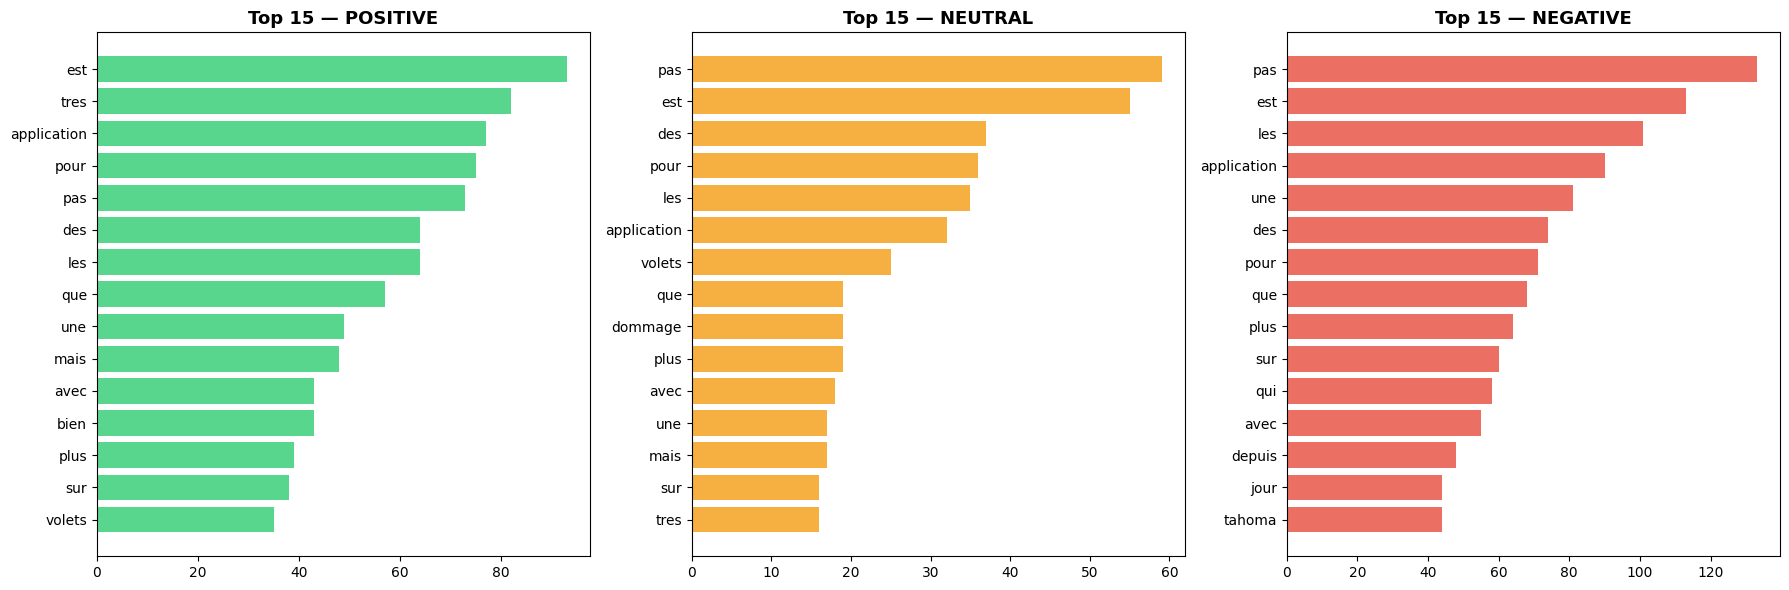

In [32]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, sat in enumerate(['positive', 'neutral', 'negative']):

    subset = df[df['satisfaction'] == sat]

    all_words = ' '.join(
        subset['clean_commentaire'].dropna().values
    ).split()

    wf = Counter(all_words).most_common(15)

    if wf:

        words, counts = zip(*wf)

        axes[i].barh(
            range(len(words)),
            counts,
            color=colors_sat[sat],
            alpha=0.8
        )

        axes[i].set_yticks(range(len(words)))
        axes[i].set_yticklabels(words)

        axes[i].invert_yaxis()

        axes[i].set_title(
            f'Top 15 — {sat.upper()}',
            fontsize=13,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

# **Dataset Nettoyé**

In [36]:
# Sauvegarder le dataset nettoyé
df.to_json(
    'dataset_Analyse_des_sentiments_clean.json',
    orient='records',
    force_ascii=False
)

print("Dataset sauvegardé avec succès")

Dataset sauvegardé avec succès


In [37]:
from google.colab import files

files.download('dataset_Analyse_des_sentiments_clean.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>